<a href="https://colab.research.google.com/github/pet2/Portifolio/blob/main/Pipeline_ENEM_IDH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Data Engineering: ETL de Dados do ENEM e IDH

Este notebook demonstra a construção de um pipeline ETL completo utilizando Python e Pandas.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

sns.set_theme(style='whitegrid')

def criar_dados_simulados():
    np.random.seed(42)
    n_inscritos = 5000
    df_enem_sim = pd.DataFrame({
        'NU_INSCRICAO': range(1000, 1000 + n_inscritos),
        'TP_SEXO': np.random.choice(['M', 'F', ' m ', 'F '], n_inscritos),
        'NU_NOTA_CN': np.random.normal(500, 100, n_inscritos),
        'NU_NOTA_CH': np.random.normal(520, 90, n_inscritos),
        'NU_NOTA_MT': np.random.normal(480, 110, n_inscritos),
        'NU_NOTA_REDACAO': np.random.normal(600, 150, n_inscritos),
        'CO_MUNICIPIO_RESIDENCIA': np.random.choice([1100015, 3550308, 3304557, 4106902, 2304400], n_inscritos),
        'IDADE_STR': [str(np.random.randint(15, 60)) for _ in range(n_inscritos)]
    })
    df_enem_sim.loc[np.random.choice(n_inscritos, 50), 'NU_NOTA_MT'] = np.nan
    df_enem_sim.loc[0:10, 'NU_NOTA_REDACAO'] = 1500
    df_enem_sim.to_csv('MICRODADOS_ENEM_SIMULADO.csv', index=False, sep=';', encoding='utf-8')

    df_idh_sim = pd.DataFrame({
        'cod_municipio': [1100015, 3550308, 3304557, 4106902, 2304400],
        'nome_municipio': ['Alta Floresta D\'Oeste', 'São Paulo', 'Rio de Janeiro', 'Curitiba', 'Fortaleza'],
        'sg_uf': ['RO', 'SP', 'RJ', 'PR', 'CE'],
        'IDHM_2010': [0.641, 0.805, 0.799, 0.823, 0.754]
    })
    df_idh_sim.to_excel('IDHM_MUNICIPIOS_SIMULADO.xlsx', index=False)

criar_dados_simulados()
print('Dados simulados criados.')

Dados simulados criados.


In [ ]:
colunas_interesse = ['NU_INSCRICAO', 'TP_SEXO', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'CO_MUNICIPIO_RESIDENCIA', 'IDADE_STR']
df_enem = pd.read_csv('MICRODADOS_ENEM_SIMULADO.csv', usecols=colunas_interesse, sep=';')
df_idh = pd.read_excel('IDHM_MUNICIPIOS_SIMULADO.xlsx')

colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_enem[colunas_notas] = df_enem[colunas_notas].fillna(0)
df_enem['IDADE'] = df_enem['IDADE_STR'].astype(int)
df_enem['TP_SEXO'] = df_enem['TP_SEXO'].str.strip().str.upper()
df_enem['NOTA_MEDIA_GERAL'] = df_enem[colunas_notas].mean(axis=1)

df_merged = df_enem.merge(df_idh, left_on='CO_MUNICIPIO_RESIDENCIA', right_on='cod_municipio', how='left')
display(df_merged.head())

### Média de Notas por Município
Calculando a performance média geral agrupada por cidade.

In [14]:
media_por_municipio = df_merged.groupby('nome_municipio')['NOTA_MEDIA_GERAL'].mean().sort_values(ascending=False).reset_index()

print("Ranking de Notas Médias por Município:")
display(media_por_municipio)

Ranking de Notas Médias por Município:


,nome_municipio,NOTA_MEDIA_GERAL
0,São Paulo,526.276751
1,Alta Floresta D'Oeste,525.161872
2,Fortaleza,524.649730
3,Rio de Janeiro,524.468415
4,Curitiba,523.142915


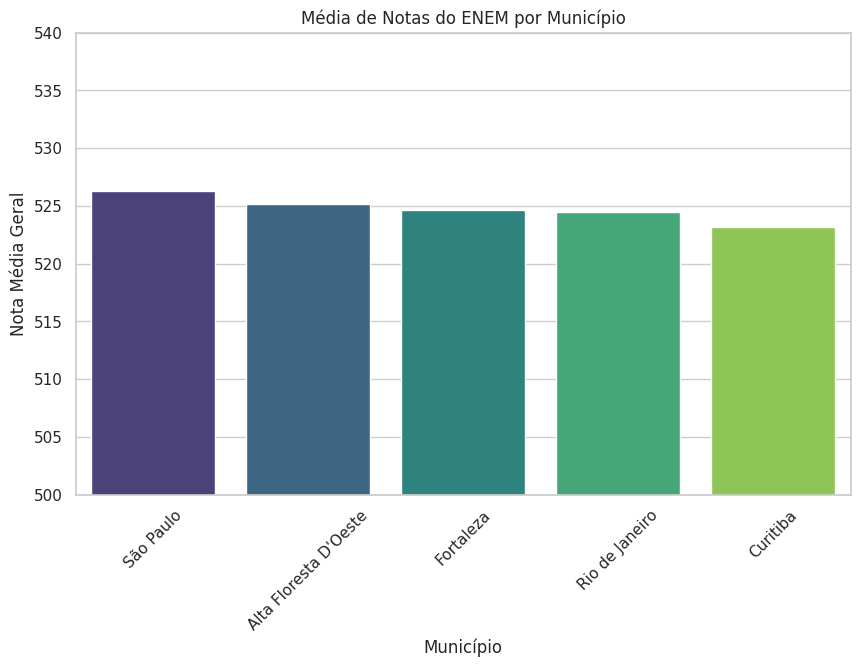

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=media_por_municipio, x='nome_municipio', y='NOTA_MEDIA_GERAL', hue='nome_municipio', palette='viridis', legend=False)
plt.title('Média de Notas do ENEM por Município')
plt.xlabel('Município')
plt.ylabel('Nota Média Geral')
plt.xticks(rotation=45)
plt.ylim(500, 540)  # Ajuste para destacar as diferenças
plt.show()

### Distribuição de Notas por Sexo
Comparando o desempenho entre candidatos masculinos e femininos.

### Correlação entre IDHM e Desempenho
Vamos analisar se existe uma relação linear entre o Índice de Desenvolvimento Humano Municipal (IDHM) e a nota média obtida pelos inscritos.

Coeficiente de Correlação de Pearson: -0.0049


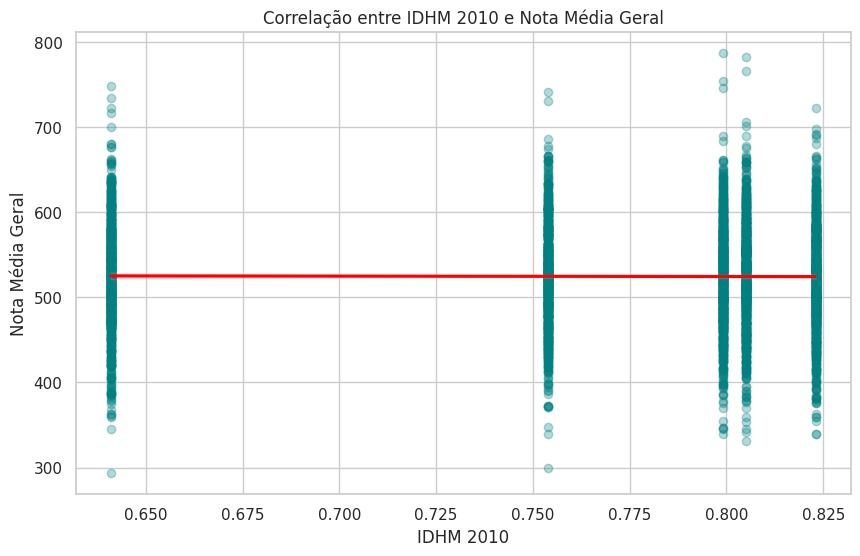

In [16]:
# Calcular o coeficiente de correlação de Pearson
correlacao = df_merged['IDHM_2010'].corr(df_merged['NOTA_MEDIA_GERAL'])

print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")

# Visualização com Regressão Linear
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='IDHM_2010', y='NOTA_MEDIA_GERAL',
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Correlação entre IDHM 2010 e Nota Média Geral')
plt.xlabel('IDHM 2010')
plt.ylabel('Nota Média Geral')
plt.show()

### Correlação entre Idade e Desempenho
Vamos verificar se a idade do inscrito possui alguma relação com a sua nota média geral.

Coeficiente de Correlação (Idade vs Nota): 0.0306


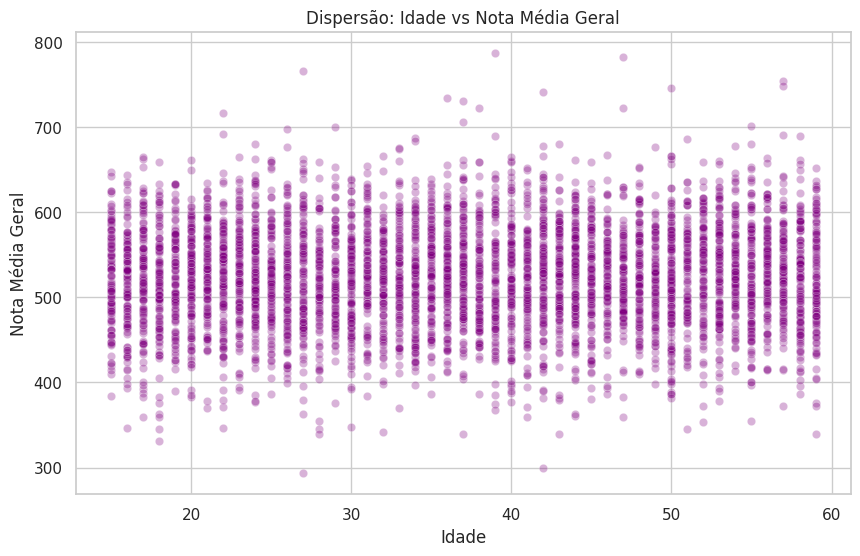

In [17]:
# Calcular a correlação entre Idade e Nota Média
correlacao_idade = df_merged['IDADE'].corr(df_merged['NOTA_MEDIA_GERAL'])

print(f"Coeficiente de Correlação (Idade vs Nota): {correlacao_idade:.4f}")

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='IDADE', y='NOTA_MEDIA_GERAL', alpha=0.3, color='purple')
plt.title('Dispersão: Idade vs Nota Média Geral')
plt.xlabel('Idade')
plt.ylabel('Nota Média Geral')
plt.show()